In [31]:
# Dependencies for this project are listed in requirements.txt
# Install with: pip install -r requirements.txt
print("Environment ready.")

Environment ready.


In [32]:
# ==========================================
# REQUIRED LIBRARIES IMPORT
# ==========================================

# Pandas: Main tool for data manipulation and analysis of tabular data
import pandas as pd

# NumPy: Support for large multidimensional arrays and mathematical functions
import numpy as np

# Matplotlib: Base library for creating static and animated charts
import matplotlib.pyplot as plt

# Seaborn: High-level interface for attractive statistical graphics
import seaborn as sns

# SciPy Stats: Statistical functions including normal distribution for safety stock
from scipy import stats

# Display configuration for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Optional configuration for better visualization in the portfolio
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Libraries successfully loaded and environment configured.")

Libraries successfully loaded and environment configured.


## STEP 1: DATA LOADING & EXPLORATION

In [33]:
# ==========================================
# 1.1 LOAD ALL SHEETS FROM DATASET
# ==========================================

# The Kaizen Analytics dataset contains 4 sheets:
# - Sales Data: Historical order transactions (33,919 records)
# - Inventory Control: Current inventory levels and costs (303 SKUs)
# - SKU Items: SKU ID to Name mapping (303 SKUs)
# - Warehouse: Warehouse location details (4 warehouses)

file_path = 'dataset_kaizen analytics.xlsx'

# Load each sheet into separate dataframes
df_sales = pd.read_excel(file_path, sheet_name='Sales Data')
df_inventory = pd.read_excel(file_path, sheet_name='Inventory Control')
df_sku = pd.read_excel(file_path, sheet_name='SKU Items')
df_warehouse = pd.read_excel(file_path, sheet_name='Warehouse')

print("✓ All 4 sheets loaded successfully.")
print(f"\nDataset shapes:")
print(f"  Sales Data:        {df_sales.shape[0]:>6,} rows × {df_sales.shape[1]} columns")
print(f"  Inventory Control: {df_inventory.shape[0]:>6,} rows × {df_inventory.shape[1]} columns")
print(f"  SKU Items:         {df_sku.shape[0]:>6,} rows × {df_sku.shape[1]} columns")
print(f"  Warehouse:         {df_warehouse.shape[0]:>6,} rows × {df_warehouse.shape[1]} columns")

✓ All 4 sheets loaded successfully.

Dataset shapes:
  Sales Data:        33,919 rows × 13 columns
  Inventory Control:    303 rows × 10 columns
  SKU Items:            303 rows × 2 columns
  Warehouse:              4 rows × 6 columns


In [34]:
# ==========================================
# 1.2 INSPECT SALES DATA STRUCTURE
# ==========================================

print("SALES DATA - Column Info:")
print(df_sales.info())
print("\n" + "="*60 + "\n")

print("SALES DATA - First 5 rows:")
display(df_sales.head())
print("\n" + "="*60 + "\n")

print("SALES DATA - Null values:")
print(df_sales.isnull().sum())
print("\n" + "="*60 + "\n")

print("SALES DATA - Basic statistics:")
display(df_sales.describe())

SALES DATA - Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 33919 entries, 0 to 33918
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order Number     33919 non-null  str           
 1   Order Date       33919 non-null  datetime64[us]
 2   SKU ID           33919 non-null  str           
 3   Warehouse ID     33919 non-null  str           
 4   Customer Type    33919 non-null  str           
 5   Order Quantity   33919 non-null  float64       
 6   Unit Sale Price  33919 non-null  float64       
 7   Revenue          33919 non-null  int64         
 8   Unnamed: 8       0 non-null      float64       
 9   Unnamed: 9       0 non-null      float64       
 10  Unnamed: 10      1 non-null      float64       
 11  Unnamed: 11      1 non-null      float64       
 12  Unnamed: 12      1 non-null      float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(4)
memory usage: 3.4 MB
None

,Order Number,Order Date,SKU ID,Warehouse ID,Customer Type,Order Quantity,Unit Sale Price,Revenue,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,SO - 018900,2021-01-01,3551CA,GUT930,Export,105.00,7.07,742,NaN,NaN,NaN,NaN,NaN
1,SO - 018901,2021-01-01,3079BA,AXW291,Wholesale,151.00,134.50,20310,NaN,NaN,NaN,NaN,NaN
2,SO - 018902,2021-01-01,3250CA,AXW291,Distributor,300.00,34.75,10426,NaN,NaN,NaN,NaN,NaN
3,SO - 018903,2021-01-01,1161AA,GUT930,Wholesale,50.00,136.59,6830,NaN,NaN,NaN,NaN,NaN
4,SO - 018904,2021-01-01,3512AA,GUT930,Distributor,1000.00,0.10,103,NaN,NaN,NaN,NaN,NaN




SALES DATA - Null values:
Order Number           0
Order Date             0
SKU ID                 0
Warehouse ID           0
Customer Type          0
Order Quantity         0
Unit Sale Price        0
Revenue                0
Unnamed: 8         33919
Unnamed: 9         33919
Unnamed: 10        33918
Unnamed: 11        33918
Unnamed: 12        33918
dtype: int64


SALES DATA - Basic statistics:


,Order Date,Order Quantity,Unit Sale Price,Revenue,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
count,33919,33919.00,33919.00,33919.00,0.00,0.00,1.00,1.00,1.00
mean,2022-02-04 15:42:13.553465,432.79,4659.34,15148.05,NaN,NaN,2523.00,12.01,210.00
min,2021-01-01 00:00:00,0.00,0.10,0.00,NaN,NaN,2523.00,12.01,210.00
25%,2021-07-17 00:00:00,2.00,30.00,215.00,NaN,NaN,2523.00,12.01,210.00
50%,2022-01-30 00:00:00,6.00,73.00,1475.00,NaN,NaN,2523.00,12.01,210.00
75%,2022-08-15 00:00:00,36.29,740.82,8551.00,NaN,NaN,2523.00,12.01,210.00
max,2023-07-30 00:00:00,111770.00,175000.00,2569984.00,NaN,NaN,2523.00,12.01,210.00
std,NaN,2382.90,20140.35,59448.16,NaN,NaN,NaN,NaN,NaN


In [35]:
# ==========================================
# 1.3 INSPECT INVENTORY CONTROL STRUCTURE
# ==========================================

print("INVENTORY CONTROL - Column Info:")
print(df_inventory.info())
print("\n" + "="*60 + "\n")

print("INVENTORY CONTROL - First 5 rows:")
display(df_inventory.head())
print("\n" + "="*60 + "\n")

print("INVENTORY CONTROL - Basic statistics:")
display(df_inventory.describe())

INVENTORY CONTROL - Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SKU ID                      303 non-null    str    
 1   Vendor Name                 303 non-null    str    
 2   Warehouse ID                303 non-null    str    
 3   Current Inventory Quantity  303 non-null    float64
 4   Cost per SKU                303 non-null    float64
 5   Total Value                 303 non-null    float64
 6   Units (Nos/Kg)              303 non-null    str    
 7   Average Lead Time (days)    303 non-null    int64  
 8   Maximum Lead Time (days)    303 non-null    int64  
 9   Unit Price                  303 non-null    float64
dtypes: float64(4), int64(2), str(4)
memory usage: 23.8 KB
None


INVENTORY CONTROL - First 5 rows:


,SKU ID,Vendor Name,Warehouse ID,Current Inventory Quantity,Cost per SKU,Total Value,Units (Nos/Kg),Average Lead Time (days),Maximum Lead Time (days),Unit Price
0,1009AA,McKesson Corp,NXH382,7210.00,20.13,145168.17,Kg,30,48,28.76
1,1077CA,McKesson Corp,GUT930,46516.00,16.08,748181.49,Kg,45,70,22.98
2,1083AA,Kinray Ltd,FLR025,48210.00,20.31,979337.94,Kg,45,68,29.02
3,1116CA,Accord Ltd,AXW291,33398.00,22.96,766818.08,Kg,90,140,32.80
4,1126CA,AstraZeneca,NXH382,39270.00,22.96,901639.20,Kg,45,62,32.80




INVENTORY CONTROL - Basic statistics:


,Current Inventory Quantity,Cost per SKU,Total Value,Average Lead Time (days),Maximum Lead Time (days),Unit Price
count,303.00,303.00,303.00,303.00,303.00,303.00
mean,6586.76,2941.73,178648.44,52.94,76.83,4202.48
std,26520.16,12819.46,316416.09,30.97,44.79,18313.51
min,0.00,0.07,0.00,15.00,20.00,0.10
25%,22.00,21.00,5149.03,30.00,43.00,30.00
50%,219.00,98.00,45730.47,45.00,68.00,140.00
75%,1298.25,634.32,161832.04,60.00,92.50,906.17
max,342553.00,122500.00,1910629.36,120.00,192.00,175000.00


In [36]:
# ==========================================
# 1.4 INSPECT SKU ITEMS & WAREHOUSE
# ==========================================

print("SKU ITEMS - First 10 rows:")
display(df_sku.head(10))
print("\n" + "="*60 + "\n")

print("WAREHOUSE - All locations:")
display(df_warehouse)
print("\n" + "="*60 + "\n")

print("✓ Step 1 completed: Initial data exploration finished.")

SKU ITEMS - First 10 rows:


,SKU ID,SKU Name
0,1009AA,Product 001
1,1077CA,Product 002
2,1083AA,Product 003
3,1116CA,Product 004
4,1126CA,Product 005
5,1130AA,Product 006
6,1145BA,Product 007
7,1161AA,Product 008
8,1163CA,Product 009
9,1193BA,Product 010




WAREHOUSE - All locations:


,Warehouse Code,City,Province,Country,Latitude,Longitude
0,GUT930,Martensville,Saskatchewan,Canada,52.29,-106.67
1,AXW291,Stanstead,Quebec,Canada,45.02,-72.10
2,NXH382,Saint-Pamphile,Quebec,Canada,46.97,-69.78
3,FLR025,Estevan,Saskatchewan,Canada,49.14,-102.99




✓ Step 1 completed: Initial data exploration finished.


## STEP 2: DATA CLEANING & PREPARATION

In [37]:
# ==========================================
# 2.1 DROP UNUSED COLUMNS FROM SALES DATA
# ==========================================

# The columns 'Unnamed: 8' through 'Unnamed: 12' are empty (33,918+ nulls out of 33,919 rows)
# These columns add no value to the analysis and should be removed

# Get column names before cleaning
print("Columns BEFORE cleaning:")
print(df_sales.columns.tolist())
print(f"Total columns: {len(df_sales.columns)}")
print("\n" + "="*60 + "\n")

# Drop all columns that start with 'Unnamed'
df_sales = df_sales.loc[:, ~df_sales.columns.str.contains('Unnamed')]

# Verify columns after cleaning
print("Columns AFTER cleaning:")
print(df_sales.columns.tolist())
print(f"Total columns: {len(df_sales.columns)}")
print("\n" + "="*60 + "\n")

print("✓ Unused columns removed successfully.")

Columns BEFORE cleaning:
['Order Number ', 'Order Date', 'SKU ID', 'Warehouse ID', 'Customer Type', 'Order Quantity', 'Unit Sale Price', 'Revenue', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']
Total columns: 13


Columns AFTER cleaning:
['Order Number ', 'Order Date', 'SKU ID', 'Warehouse ID', 'Customer Type', 'Order Quantity', 'Unit Sale Price', 'Revenue']
Total columns: 8


✓ Unused columns removed successfully.


In [38]:
# ==========================================
# 2.2 CREATE TIME FEATURES FROM ORDER DATE
# ==========================================

# For demand analysis, we need to aggregate sales by time periods (Year, Month, Quarter)
# We'll extract these features from the 'Order Date' column

# Extract Year from Order Date
df_sales['Year'] = df_sales['Order Date'].dt.year

# Extract Month number (1-12)
df_sales['Month'] = df_sales['Order Date'].dt.month

# Extract Quarter (Q1, Q2, Q3, Q4)
df_sales['Quarter'] = df_sales['Order Date'].dt.quarter

# Create a Year-Month column for easier grouping (format: 2021-01, 2021-02, etc.)
df_sales['Year-Month'] = df_sales['Order Date'].dt.to_period('M').astype(str)

# Verify new columns
print("New time columns created:")
print(df_sales[['Order Date', 'Year', 'Month', 'Quarter', 'Year-Month']].head(10))
print("\n" + "="*60 + "\n")

print("✓ Time features extracted successfully.")

New time columns created:
  Order Date  Year  Month  Quarter Year-Month
0 2021-01-01  2021      1        1    2021-01
1 2021-01-01  2021      1        1    2021-01
2 2021-01-01  2021      1        1    2021-01
3 2021-01-01  2021      1        1    2021-01
4 2021-01-01  2021      1        1    2021-01
5 2021-01-01  2021      1        1    2021-01
6 2021-01-01  2021      1        1    2021-01
7 2021-01-01  2021      1        1    2021-01
8 2021-01-01  2021      1        1    2021-01
9 2021-01-01  2021      1        1    2021-01


✓ Time features extracted successfully.


In [39]:
# ==========================================
# 2.3 CALCULATE MONTHLY DEMAND BY SKU
# ==========================================

# For inventory optimization, we need to know the monthly demand for each SKU
# We'll aggregate Order Quantity by SKU and Year-Month

# Group sales by SKU and Year-Month, summing the quantities
monthly_demand = df_sales.groupby(['SKU ID', 'Year-Month'])['Order Quantity'].sum().reset_index()

# Rename column for clarity
monthly_demand.rename(columns={'Order Quantity': 'Monthly Demand'}, inplace=True)

# Show sample of monthly demand
print("Monthly Demand by SKU - First 20 rows:")
display(monthly_demand.head(20))
print("\n" + "="*60 + "\n")

# Show statistics
print(f"Total unique SKUs with demand: {monthly_demand['SKU ID'].nunique()}")
print(f"Total months in dataset: {monthly_demand['Year-Month'].nunique()}")
print(f"Total records: {len(monthly_demand):,}")
print("\n" + "="*60 + "\n")

print("✓ Monthly demand calculated successfully.")

Monthly Demand by SKU - First 20 rows:


,SKU ID,Year-Month,Monthly Demand
0,1009AA,2021-01,5160.00
1,1009AA,2021-02,2849.00
2,1009AA,2021-03,6256.00
3,1009AA,2021-04,6267.00
4,1009AA,2021-05,10174.00
5,1009AA,2021-06,6531.00
6,1009AA,2021-07,1691.00
7,1009AA,2021-08,2802.00
8,1009AA,2021-09,1641.00
9,1009AA,2021-10,1863.00




Total unique SKUs with demand: 290
Total months in dataset: 31
Total records: 6,854


✓ Monthly demand calculated successfully.


In [40]:
# ==========================================
# 2.4 MERGE SALES WITH INVENTORY DATA
# ==========================================

# We need to combine sales data with inventory data to have all information in one place
# This will allow us to calculate inventory parameters with both demand and cost data

# First, merge monthly_demand with inventory control data
df_merged = monthly_demand.merge(
    df_inventory[['SKU ID', 'Cost per SKU', 'Average Lead Time (days)', 
                  'Maximum Lead Time (days)', 'Unit Price', 'Vendor Name']],
    on='SKU ID',
    how='left'
)

# Add SKU names for better readability
df_merged = df_merged.merge(
    df_sku,
    on='SKU ID',
    how='left'
)

# Verify the merge
print("Merged dataset - First 10 rows:")
display(df_merged.head(10))
print("\n" + "="*60 + "\n")

print(f"Total records in merged dataset: {len(df_merged):,}")
print(f"Columns: {df_merged.columns.tolist()}")
print("\n" + "="*60 + "\n")

print("✓ Tables merged successfully.")

Merged dataset - First 10 rows:


,SKU ID,Year-Month,Monthly Demand,Cost per SKU,Average Lead Time (days),Maximum Lead Time (days),Unit Price,Vendor Name,SKU Name
0,1009AA,2021-01,5160.00,20.13,30,48,28.76,McKesson Corp,Product 001
1,1009AA,2021-02,2849.00,20.13,30,48,28.76,McKesson Corp,Product 001
2,1009AA,2021-03,6256.00,20.13,30,48,28.76,McKesson Corp,Product 001
3,1009AA,2021-04,6267.00,20.13,30,48,28.76,McKesson Corp,Product 001
4,1009AA,2021-05,10174.00,20.13,30,48,28.76,McKesson Corp,Product 001
5,1009AA,2021-06,6531.00,20.13,30,48,28.76,McKesson Corp,Product 001
6,1009AA,2021-07,1691.00,20.13,30,48,28.76,McKesson Corp,Product 001
7,1009AA,2021-08,2802.00,20.13,30,48,28.76,McKesson Corp,Product 001
8,1009AA,2021-09,1641.00,20.13,30,48,28.76,McKesson Corp,Product 001
9,1009AA,2021-10,1863.00,20.13,30,48,28.76,McKesson Corp,Product 001




Total records in merged dataset: 6,854
Columns: ['SKU ID', 'Year-Month', 'Monthly Demand', 'Cost per SKU', 'Average Lead Time (days)', 'Maximum Lead Time (days)', 'Unit Price', 'Vendor Name', 'SKU Name']


✓ Tables merged successfully.


In [41]:
# ==========================================
# 2.5 CHECK FOR MISSING VALUES
# ==========================================

# After merging, we need to check if there are any SKUs with missing inventory data
# Missing data could indicate SKUs that exist in sales but not in inventory control

print("Null values in merged dataset:")
print(df_merged.isnull().sum())
print("\n" + "="*60 + "\n")

# Check if any SKU has missing inventory data
skus_with_missing_data = df_merged[df_merged['Cost per SKU'].isnull()]['SKU ID'].unique()

if len(skus_with_missing_data) > 0:
    print(f"⚠ Warning: {len(skus_with_missing_data)} SKUs have missing inventory data:")
    print(skus_with_missing_data)
else:
    print("✓ All SKUs have complete inventory data.")

print("\n" + "="*60 + "\n")

Null values in merged dataset:
SKU ID                      0
Year-Month                  0
Monthly Demand              0
Cost per SKU                0
Average Lead Time (days)    0
Maximum Lead Time (days)    0
Unit Price                  0
Vendor Name                 0
SKU Name                    0
dtype: int64


✓ All SKUs have complete inventory data.




In [42]:
# ==========================================
# 2.6 CALCULATE AVERAGE DAILY DEMAND BY SKU
# ==========================================

# For inventory calculations, we need the average DAILY demand (not monthly)
# We'll calculate this by dividing monthly demand by 30 days (approximation)

# Calculate daily demand (Monthly Demand / 30 days)
df_merged['Daily Demand'] = df_merged['Monthly Demand'] / 30

# Now aggregate by SKU to get overall statistics
sku_stats = df_merged.groupby('SKU ID').agg({
    'Daily Demand': ['mean', 'std', 'count'],
    'Monthly Demand': 'sum',
    'Cost per SKU': 'first',
    'Average Lead Time (days)': 'first',
    'Maximum Lead Time (days)': 'first',
    'Unit Price': 'first',
    'Vendor Name': 'first',
    'SKU Name': 'first'
}).reset_index()

# Flatten column names (remove multi-level index)
sku_stats.columns = ['SKU ID', 'Avg Daily Demand', 'StdDev Daily Demand', 'Months with Demand', 
                      'Total Demand', 'Cost per SKU', 'Avg Lead Time', 'Max Lead Time', 
                      'Unit Price', 'Vendor Name', 'SKU Name']

# Show results
print("SKU Statistics - First 10 rows:")
display(sku_stats.head(10))
print("\n" + "="*60 + "\n")

print(f"Total SKUs analyzed: {len(sku_stats)}")
print("\n" + "="*60 + "\n")

print("✓ Step 2 completed: Data cleaning and preparation finished.")

SKU Statistics - First 10 rows:


,SKU ID,Avg Daily Demand,StdDev Daily Demand,Months with Demand,Total Demand,Cost per SKU,Avg Lead Time,Max Lead Time,Unit Price,Vendor Name,SKU Name
0,1009AA,92.90,96.12,31,86398.00,20.13,30,48,28.76,McKesson Corp,Product 001
1,1077CA,537.89,405.07,28,451826.00,16.08,45,70,22.98,McKesson Corp,Product 002
2,1083AA,444.37,363.88,29,386606.00,20.31,45,68,29.02,Kinray Ltd,Product 003
3,1116CA,591.59,539.92,24,425947.00,22.96,90,140,32.80,Accord Ltd,Product 004
4,1126CA,478.25,487.66,29,416080.00,22.96,45,62,32.80,AstraZeneca,Product 005
5,1130AA,112.93,142.81,29,98250.00,12.09,90,139,17.27,Sun Ltd,Product 006
6,1145BA,17.50,23.99,28,14703.00,59.71,45,60,85.30,Mylan Group,Product 007
7,1161AA,20.55,16.39,27,16646.00,95.61,90,142,136.59,Kinray Ltd,Product 008
8,1163CA,20.63,20.77,30,18564.00,66.26,90,136,94.66,Macoven Group,Product 009
9,1193BA,24.83,32.01,29,21602.00,570.50,90,138,815.00,Major Corp,Product 010




Total SKUs analyzed: 290


✓ Step 2 completed: Data cleaning and preparation finished.


## STEP 3: DEMAND ANALYSIS

In [43]:
# ==========================================
# 3.1 CALCULATE COEFFICIENT OF VARIATION (CV)
# ==========================================

# The Coefficient of Variation measures demand variability relative to the mean
# CV = (Standard Deviation / Mean) * 100
# Lower CV = more stable demand, Higher CV = more erratic demand

# Calculate CV for each SKU
sku_stats['CV (%)'] = (sku_stats['StdDev Daily Demand'] / sku_stats['Avg Daily Demand']) * 100

# Classify demand variability based on CV
# Low CV (< 50%): Stable demand
# Medium CV (50-100%): Moderate variability  
# High CV (> 100%): Erratic demand

def classify_variability(cv):
    if cv < 50:
        return 'Low'
    elif cv < 100:
        return 'Medium'
    else:
        return 'High'

sku_stats['Demand Variability'] = sku_stats['CV (%)'].apply(classify_variability)

# Show results sorted by CV
print("SKU Statistics with Coefficient of Variation - Top 10 by CV:")
display(sku_stats.nlargest(10, 'CV (%)')[['SKU ID', 'SKU Name', 'Avg Daily Demand', 
                                            'StdDev Daily Demand', 'CV (%)', 'Demand Variability']])
print("\n" + "="*60 + "\n")

# Count SKUs by variability class
print("SKU Distribution by Demand Variability:")
print(sku_stats['Demand Variability'].value_counts())
print("\n" + "="*60 + "\n")

print("✓ Coefficient of Variation calculated successfully.")

SKU Statistics with Coefficient of Variation - Top 10 by CV:


,SKU ID,SKU Name,Avg Daily Demand,StdDev Daily Demand,CV (%),Demand Variability
274,3461CA,Product 288,45.46,224.12,492.96,High
270,3413AA,Product 284,17.19,78.58,457.23,High
102,1956AA,Product 104,0.91,3.99,438.08,High
159,2342CA,Product 161,90.34,365.41,404.50,High
48,1484BA,Product 049,1.11,3.97,356.92,High
119,2041CA,Product 121,2.15,7.38,343.54,High
118,2039CA,Product 120,2.36,8.03,340.63,High
203,2680BA,Product 205,11.79,39.77,337.25,High
136,2189CA,Product 138,1.50,4.67,310.59,High
125,2066AA,Product 127,0.75,2.30,305.32,High




SKU Distribution by Demand Variability:
Demand Variability
High      144
Medium    134
Low        12
Name: count, dtype: int64


✓ Coefficient of Variation calculated successfully.


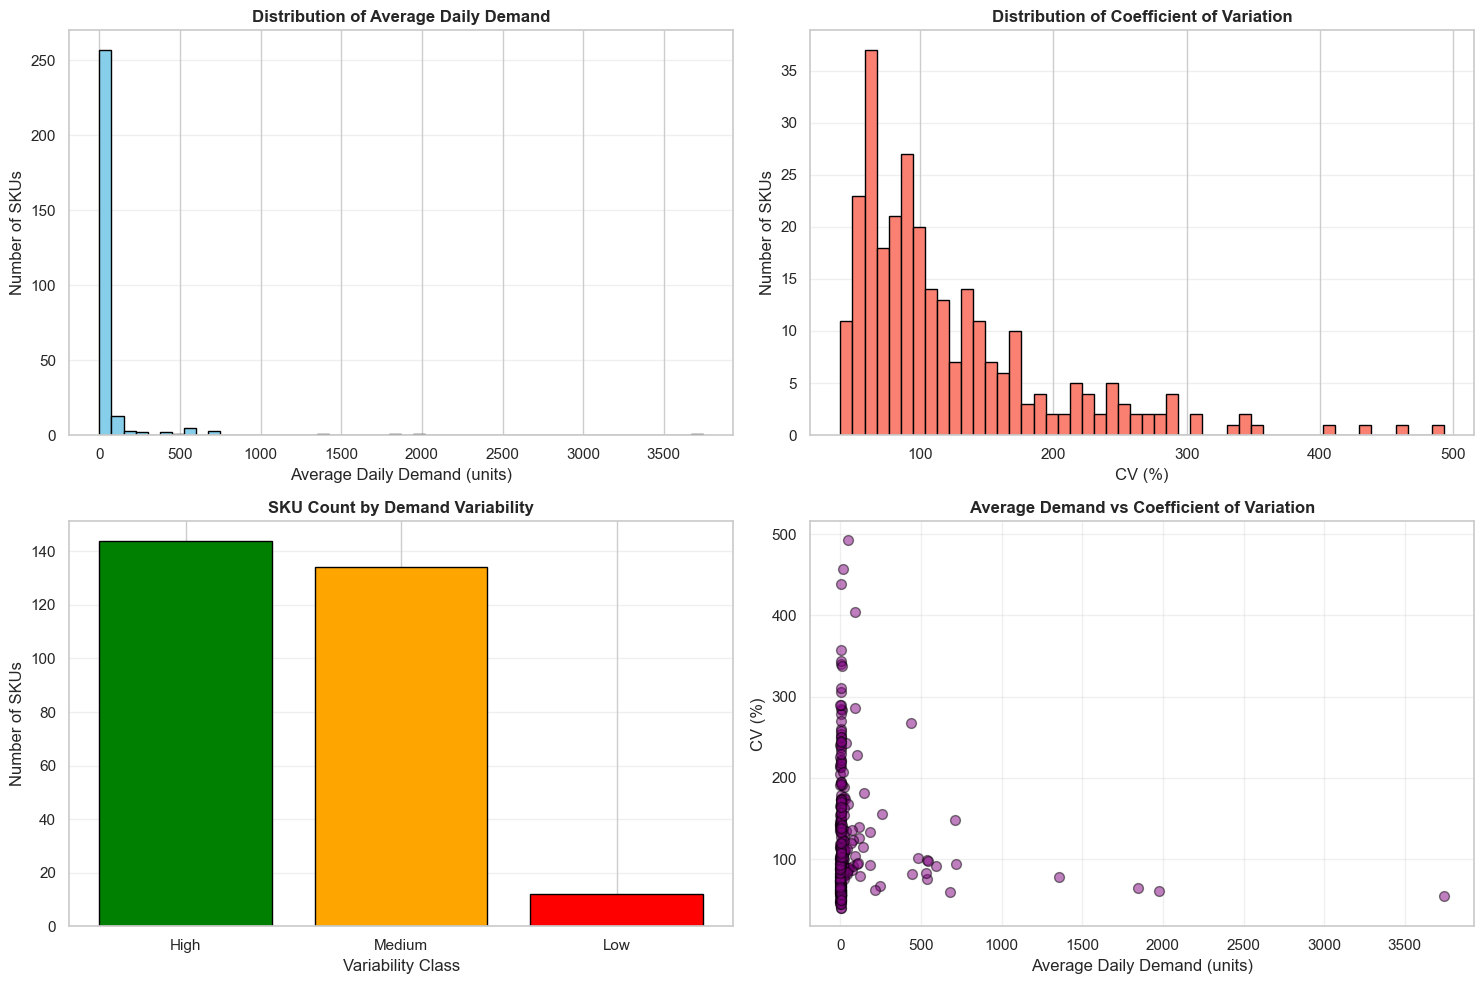



✓ Demand distribution visualized successfully.


In [44]:
# ==========================================
# 3.2 VISUALIZE DEMAND DISTRIBUTION
# ==========================================

# Create visualizations to understand demand patterns

# Set figure size
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogram of Average Daily Demand
axes[0, 0].hist(sku_stats['Avg Daily Demand'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Average Daily Demand', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Average Daily Demand (units)')
axes[0, 0].set_ylabel('Number of SKUs')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of Coefficient of Variation
axes[0, 1].hist(sku_stats['CV (%)'], bins=50, color='salmon', edgecolor='black')
axes[0, 1].set_title('Distribution of Coefficient of Variation', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('CV (%)')
axes[0, 1].set_ylabel('Number of SKUs')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Bar chart: SKUs by Demand Variability
variability_counts = sku_stats['Demand Variability'].value_counts()
axes[1, 0].bar(variability_counts.index, variability_counts.values, 
               color=['green', 'orange', 'red'], edgecolor='black')
axes[1, 0].set_title('SKU Count by Demand Variability', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Variability Class')
axes[1, 0].set_ylabel('Number of SKUs')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Scatter plot: Avg Demand vs CV
axes[1, 1].scatter(sku_stats['Avg Daily Demand'], sku_stats['CV (%)'], 
                   alpha=0.5, color='purple', edgecolor='black', s=50)
axes[1, 1].set_title('Average Demand vs Coefficient of Variation', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Daily Demand (units)')
axes[1, 1].set_ylabel('CV (%)')
axes[1, 1].grid(alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")
print("✓ Demand distribution visualized successfully.")

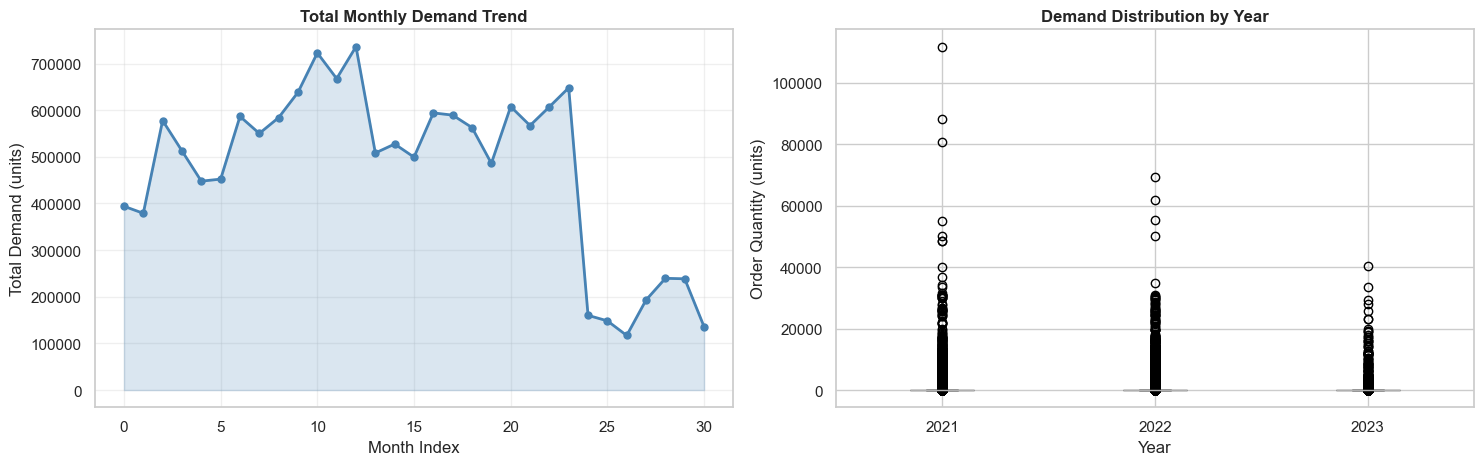


Monthly Total Demand:


,Year-Month,Total Demand
0,2021-01,394059.58
1,2021-02,378935.90
2,2021-03,577799.08
3,2021-04,512785.80
4,2021-05,447840.59
5,2021-06,452245.59
6,2021-07,586680.44
7,2021-08,550141.21
8,2021-09,584120.48
9,2021-10,638351.15




✓ Step 3 completed: Demand analysis finished.


In [45]:
# ==========================================
# 3.3 ANALYZE DEMAND TRENDS OVER TIME
# ==========================================

# Analyze how total demand has evolved over time (monthly aggregation)

# Aggregate total demand by month across all SKUs
monthly_total = df_sales.groupby('Year-Month')['Order Quantity'].sum().reset_index()
monthly_total.rename(columns={'Order Quantity': 'Total Demand'}, inplace=True)

# Create time series visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Line chart: Total demand over time
axes[0].plot(range(len(monthly_total)), monthly_total['Total Demand'], 
             marker='o', color='steelblue', linewidth=2, markersize=5)
axes[0].set_title('Total Monthly Demand Trend', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month Index')
axes[0].set_ylabel('Total Demand (units)')
axes[0].grid(alpha=0.3)
axes[0].fill_between(range(len(monthly_total)), monthly_total['Total Demand'], alpha=0.2, color='steelblue')

# 2. Box plot: Demand distribution by year
df_sales['Year'] = df_sales['Year'].astype(str)
df_sales.boxplot(column='Order Quantity', by='Year', ax=axes[1], patch_artist=True)
axes[1].set_title('Demand Distribution by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Order Quantity (units)')
axes[1].get_figure().suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Display monthly totals
print("\nMonthly Total Demand:")
display(monthly_total)
print("\n" + "="*60 + "\n")

print("✓ Step 3 completed: Demand analysis finished.")

## STEP 4: ABC CLASSIFICATION

In [46]:
# ==========================================
# 4.1 CALCULATE ANNUAL CONSUMPTION VALUE
# ==========================================

# ABC Classification categorizes SKUs based on their annual consumption value
# Class A: Top 80% of total value (high-value items)
# Class B: Next 15% of total value (medium-value items)
# Class C: Last 5% of total value (low-value items)

# Calculate annual consumption value for each SKU
# Annual Value = Total Demand * Cost per SKU
sku_stats['Annual Consumption Value'] = sku_stats['Total Demand'] * sku_stats['Cost per SKU']

# Sort by annual value in descending order
sku_stats_sorted = sku_stats.sort_values('Annual Consumption Value', ascending=False).reset_index(drop=True)

# Calculate cumulative sum and cumulative percentage
sku_stats_sorted['Cumulative Value'] = sku_stats_sorted['Annual Consumption Value'].cumsum()
total_value = sku_stats_sorted['Annual Consumption Value'].sum()
sku_stats_sorted['Cumulative %'] = (sku_stats_sorted['Cumulative Value'] / total_value) * 100

# Classify into ABC categories
def classify_abc(cumulative_pct):
    if cumulative_pct <= 80:
        return 'A'
    elif cumulative_pct <= 95:
        return 'B'
    else:
        return 'C'

sku_stats_sorted['ABC Class'] = sku_stats_sorted['Cumulative %'].apply(classify_abc)

# Display top 10 SKUs by value
print("Top 10 SKUs by Annual Consumption Value:")
display(sku_stats_sorted.head(10)[['SKU ID', 'SKU Name', 'Total Demand', 'Cost per SKU', 
                                    'Annual Consumption Value', 'Cumulative %', 'ABC Class']])
print("\n" + "="*60 + "\n")

# Count SKUs by ABC class
print("ABC Classification Summary:")
abc_summary = sku_stats_sorted['ABC Class'].value_counts().sort_index()
print(abc_summary)
print(f"\nTotal Annual Consumption Value: ${total_value:,.2f}")
print("\n" + "="*60 + "\n")

print("✓ ABC Classification completed successfully.")

Top 10 SKUs by Annual Consumption Value:


,SKU ID,SKU Name,Total Demand,Cost per SKU,Annual Consumption Value,Cumulative %,ABC Class
0,1244AA,Product 016,550590.13,42.00,23124785.28,6.43,A
1,1295CA,Product 022,133.67,122500.00,16375145.10,10.98,A
2,1281BA,Product 020,134.39,97650.00,13123155.87,14.63,A
3,1193BA,Product 010,21602.00,570.50,12323941.00,18.06,A
4,3205AA,Product 262,188.28,53410.00,10055795.63,20.85,A
5,1116CA,Product 004,425947.00,22.96,9779743.12,23.57,A
6,1126CA,Product 005,416080.00,22.96,9553196.80,26.23,A
7,2117BA,Product 132,5604.34,1696.80,9509446.75,28.87,A
8,1283CA,Product 021,126.10,68833.33,8680141.61,31.29,A
9,1967BA,Product 107,63821.50,125.06,7981197.68,33.51,A




ABC Classification Summary:
ABC Class
A     56
B     73
C    161
Name: count, dtype: int64

Total Annual Consumption Value: $359,664,497.05


✓ ABC Classification completed successfully.


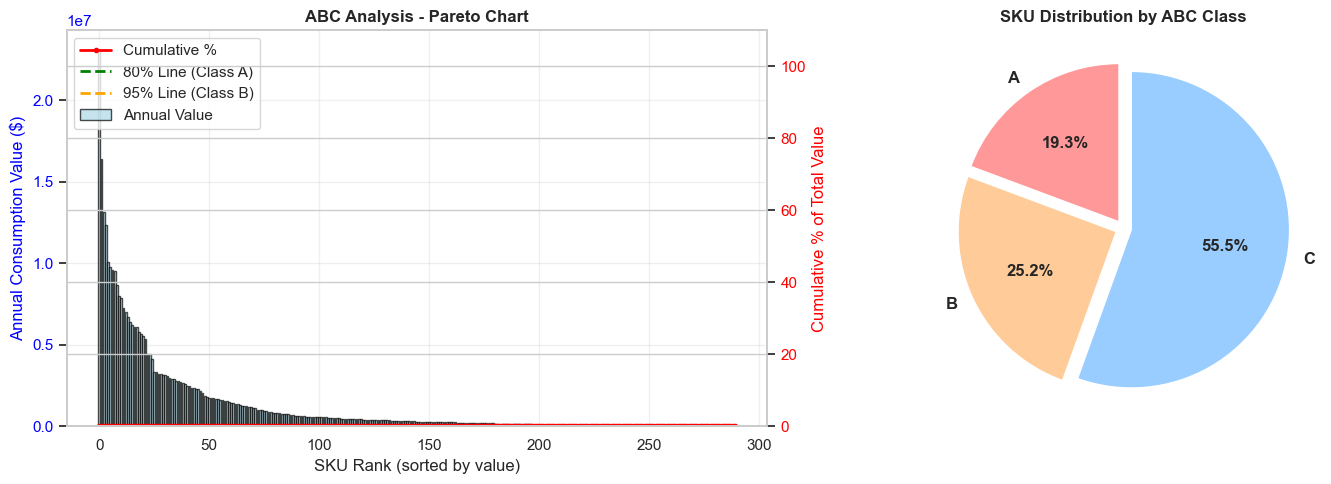



✓ ABC Classification visualized successfully.


In [47]:
# ==========================================
# 4.2 VISUALIZE ABC CLASSIFICATION
# ==========================================

# Create visualizations for ABC analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Pareto Chart: Cumulative % by SKU
axes[0].bar(range(len(sku_stats_sorted)), sku_stats_sorted['Annual Consumption Value'], 
            color='lightblue', edgecolor='black', alpha=0.7, label='Annual Value')
axes[0].plot(range(len(sku_stats_sorted)), sku_stats_sorted['Cumulative %'], 
             color='red', marker='o', linewidth=2, markersize=3, label='Cumulative %')
axes[0].axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% Line (Class A)')
axes[0].axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Line (Class B)')
axes[0].set_title('ABC Analysis - Pareto Chart', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SKU Rank (sorted by value)')
axes[0].set_ylabel('Annual Consumption Value ($)', color='blue')
axes[0].tick_params(axis='y', labelcolor='blue')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Create secondary y-axis for cumulative percentage
ax2 = axes[0].twinx()
ax2.set_ylabel('Cumulative % of Total Value', color='red')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor='red')

# 2. Pie Chart: SKU count by ABC class
abc_counts = sku_stats_sorted['ABC Class'].value_counts().sort_index()
colors_abc = ['#ff9999', '#ffcc99', '#99ccff']  # Red for A, Orange for B, Blue for C
axes[1].pie(abc_counts.values, labels=abc_counts.index, autopct='%1.1f%%', 
            colors=colors_abc, startangle=90, explode=(0.05, 0.05, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('SKU Distribution by ABC Class', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")
print("✓ ABC Classification visualized successfully.")

## STEP 5: INVENTORY PARAMETER CALCULATION

In [48]:
# ==========================================
# 5.1 CALCULATE SAFETY STOCK
# ==========================================

# Safety Stock protects against demand variability and lead time uncertainty
# Formula: Safety Stock = Z * StdDev(Daily Demand) * sqrt(Lead Time)
# Where Z = service level factor from normal distribution

# Define service level (95% = 1.645, 99% = 2.326)
SERVICE_LEVEL = 0.95
Z_SCORE = stats.norm.ppf(SERVICE_LEVEL)

print(f"Service Level: {SERVICE_LEVEL * 100}%")
print(f"Z-Score: {Z_SCORE:.3f}")
print("\n" + "="*60 + "\n")

# Calculate Safety Stock for each SKU
# Using Average Lead Time for the calculation
sku_stats_sorted['Safety Stock'] = (
    Z_SCORE * 
    sku_stats_sorted['StdDev Daily Demand'] * 
    np.sqrt(sku_stats_sorted['Avg Lead Time'])
)

# Round to whole units (cannot have fractional inventory)
sku_stats_sorted['Safety Stock'] = sku_stats_sorted['Safety Stock'].round(0)

# Display results for top 10 SKUs
print("Safety Stock Calculation - Top 10 SKUs by Annual Value:")
display(sku_stats_sorted.head(10)[['SKU ID', 'SKU Name', 'Avg Daily Demand', 
                                    'StdDev Daily Demand', 'Avg Lead Time', 
                                    'Safety Stock', 'ABC Class']])
print("\n" + "="*60 + "\n")

print("✓ Safety Stock calculated successfully.")

Service Level: 95.0%
Z-Score: 1.645


Safety Stock Calculation - Top 10 SKUs by Annual Value:


,SKU ID,SKU Name,Avg Daily Demand,StdDev Daily Demand,Avg Lead Time,Safety Stock,ABC Class
0,1244AA,Product 016,679.74,402.12,45,4437.00,A
1,1295CA,Product 022,0.17,0.09,120,2.00,A
2,1281BA,Product 020,0.17,0.10,60,1.00,A
3,1193BA,Product 010,24.83,32.01,90,500.00,A
4,3205AA,Product 262,0.22,0.14,60,2.00,A
5,1116CA,Product 004,591.59,539.92,90,8425.00,A
6,1126CA,Product 005,478.25,487.66,45,5381.00,A
7,2117BA,Product 132,6.44,4.32,120,78.00,A
8,1283CA,Product 021,0.14,0.08,60,1.00,A
9,1967BA,Product 107,75.98,94.07,120,1695.00,A




✓ Safety Stock calculated successfully.


In [49]:
# ==========================================
# 5.2 CALCULATE REORDER POINT
# ==========================================

# Reorder Point is the inventory level at which a new order should be placed
# Formula: Reorder Point = (Average Daily Demand × Average Lead Time) + Safety Stock

# Calculate Reorder Point
sku_stats_sorted['Reorder Point'] = (
    (sku_stats_sorted['Avg Daily Demand'] * sku_stats_sorted['Avg Lead Time']) + 
    sku_stats_sorted['Safety Stock']
)

# Round to whole units
sku_stats_sorted['Reorder Point'] = sku_stats_sorted['Reorder Point'].round(0)

# Display results for top 10 SKUs
print("Reorder Point Calculation - Top 10 SKUs by Annual Value:")
display(sku_stats_sorted.head(10)[['SKU ID', 'SKU Name', 'Avg Daily Demand', 
                                    'Avg Lead Time', 'Safety Stock', 'Reorder Point', 
                                    'ABC Class']])
print("\n" + "="*60 + "\n")

print("✓ Reorder Point calculated successfully.")

Reorder Point Calculation - Top 10 SKUs by Annual Value:


,SKU ID,SKU Name,Avg Daily Demand,Avg Lead Time,Safety Stock,Reorder Point,ABC Class
0,1244AA,Product 016,679.74,45,4437.00,35025.00,A
1,1295CA,Product 022,0.17,120,2.00,23.00,A
2,1281BA,Product 020,0.17,60,1.00,11.00,A
3,1193BA,Product 010,24.83,90,500.00,2735.00,A
4,3205AA,Product 262,0.22,60,2.00,15.00,A
5,1116CA,Product 004,591.59,90,8425.00,61668.00,A
6,1126CA,Product 005,478.25,45,5381.00,26902.00,A
7,2117BA,Product 132,6.44,120,78.00,851.00,A
8,1283CA,Product 021,0.14,60,1.00,9.00,A
9,1967BA,Product 107,75.98,120,1695.00,10812.00,A




✓ Reorder Point calculated successfully.


In [50]:
# ==========================================
# 5.3 CALCULATE ECONOMIC ORDER QUANTITY (EOQ)
# ==========================================

# EOQ determines the optimal order quantity that minimizes total inventory costs
# Formula: EOQ = sqrt((2 × Annual Demand × Order Cost) / Holding Cost per Unit)

# Since the dataset does not include order cost and holding cost, we'll use industry assumptions:
# - Order Cost: $100 per order (fixed cost of placing an order)
# - Holding Cost Rate: 20% of unit cost per year (typical industry standard)

ORDER_COST = 100  # $ per order
HOLDING_COST_RATE = 0.20  # 20% of unit cost per year

print(f"Order Cost: ${ORDER_COST} per order")
print(f"Holding Cost Rate: {HOLDING_COST_RATE * 100}% of unit cost per year")
print("\n" + "="*60 + "\n")

# Calculate holding cost per unit
sku_stats_sorted['Holding Cost per Unit'] = sku_stats_sorted['Cost per SKU'] * HOLDING_COST_RATE

# Calculate EOQ for each SKU
sku_stats_sorted['EOQ'] = np.sqrt(
    (2 * sku_stats_sorted['Total Demand'] * ORDER_COST) / 
    sku_stats_sorted['Holding Cost per Unit']
)

# Round to whole units
sku_stats_sorted['EOQ'] = sku_stats_sorted['EOQ'].round(0)

# Set minimum EOQ = 1 (cannot order 0 units)
sku_stats_sorted['EOQ'] = sku_stats_sorted['EOQ'].replace(0, 1)

# Display results for top 10 SKUs
print("EOQ Calculation - Top 10 SKUs by Annual Value:")
display(sku_stats_sorted.head(10)[['SKU ID', 'SKU Name', 'Total Demand', 
                                    'Cost per SKU', 'Holding Cost per Unit', 
                                    'EOQ', 'ABC Class']])
print("\n" + "="*60 + "\n")

print("✓ EOQ calculated successfully.")

Order Cost: $100 per order
Holding Cost Rate: 20.0% of unit cost per year


EOQ Calculation - Top 10 SKUs by Annual Value:


,SKU ID,SKU Name,Total Demand,Cost per SKU,Holding Cost per Unit,EOQ,ABC Class
0,1244AA,Product 016,550590.13,42.00,8.40,3621.00,A
1,1295CA,Product 022,133.67,122500.00,24500.00,1.00,A
2,1281BA,Product 020,134.39,97650.00,19530.00,1.00,A
3,1193BA,Product 010,21602.00,570.50,114.10,195.00,A
4,3205AA,Product 262,188.28,53410.00,10682.00,2.00,A
5,1116CA,Product 004,425947.00,22.96,4.59,4307.00,A
6,1126CA,Product 005,416080.00,22.96,4.59,4257.00,A
7,2117BA,Product 132,5604.34,1696.80,339.36,57.00,A
8,1283CA,Product 021,126.10,68833.33,13766.67,1.00,A
9,1967BA,Product 107,63821.50,125.06,25.01,714.00,A




✓ EOQ calculated successfully.


In [51]:
# ==========================================
# 5.4 CALCULATE NUMBER OF ORDERS PER YEAR
# ==========================================

# Calculate how many orders per year are needed based on EOQ
# Orders per Year = Annual Demand / EOQ

sku_stats_sorted['Orders per Year'] = (sku_stats_sorted['Total Demand'] / sku_stats_sorted['EOQ']).round(1)

# Calculate days between orders (assuming 365 days per year)
sku_stats_sorted['Days Between Orders'] = (365 / sku_stats_sorted['Orders per Year']).round(0)

# Display complete inventory parameters for top 10 SKUs
print("Complete Inventory Parameters - Top 10 SKUs by Annual Value:")
display(sku_stats_sorted.head(10)[['SKU ID', 'SKU Name', 'ABC Class', 'Demand Variability',
                                    'Avg Daily Demand', 'Safety Stock', 'Reorder Point', 
                                    'EOQ', 'Orders per Year', 'Days Between Orders']])
print("\n" + "="*60 + "\n")

# Summary statistics by ABC Class
print("Inventory Parameters Summary by ABC Class:")
summary_by_abc = sku_stats_sorted.groupby('ABC Class').agg({
    'Safety Stock': 'mean',
    'Reorder Point': 'mean',
    'EOQ': 'mean',
    'Orders per Year': 'mean'
}).round(0)
display(summary_by_abc)
print("\n" + "="*60 + "\n")

print("✓ Step 5 completed: Inventory parameters calculated successfully.")

Complete Inventory Parameters - Top 10 SKUs by Annual Value:


,SKU ID,SKU Name,ABC Class,Demand Variability,Avg Daily Demand,Safety Stock,Reorder Point,EOQ,Orders per Year,Days Between Orders
0,1244AA,Product 016,A,Medium,679.74,4437.00,35025.00,3621.00,152.10,2.00
1,1295CA,Product 022,A,Medium,0.17,2.00,23.00,1.00,133.70,3.00
2,1281BA,Product 020,A,Medium,0.17,1.00,11.00,1.00,134.40,3.00
3,1193BA,Product 010,A,High,24.83,500.00,2735.00,195.00,110.80,3.00
4,3205AA,Product 262,A,Medium,0.22,2.00,15.00,2.00,94.10,4.00
5,1116CA,Product 004,A,Medium,591.59,8425.00,61668.00,4307.00,98.90,4.00
6,1126CA,Product 005,A,High,478.25,5381.00,26902.00,4257.00,97.70,4.00
7,2117BA,Product 132,A,Medium,6.44,78.00,851.00,57.00,98.30,4.00
8,1283CA,Product 021,A,Medium,0.14,1.00,9.00,1.00,126.10,3.00
9,1967BA,Product 107,A,High,75.98,1695.00,10812.00,714.00,89.40,4.00




Inventory Parameters Summary by ABC Class:


,Safety Stock,Reorder Point,EOQ,Orders per Year
ABC Class,,,,
A,1790.00,12881.00,2045.00,68.00
B,587.00,3909.00,1411.00,26.00
C,390.00,1415.00,1581.00,9.00




✓ Step 5 completed: Inventory parameters calculated successfully.


## STEP 6: RESULTS & RECOMMENDATIONS

In [52]:
# ==========================================
# 6.1 IDENTIFY HIGH-RISK SKUs
# ==========================================

# High-risk SKUs are those with both high demand variability AND long lead times
# These SKUs require extra attention and potentially higher safety stock

# Define risk criteria
HIGH_CV_THRESHOLD = 100  # CV > 100% is high variability
LONG_LEAD_TIME_THRESHOLD = 60  # Lead time > 60 days is long

# Flag high-risk SKUs
sku_stats_sorted['High Risk'] = (
    (sku_stats_sorted['CV (%)'] > HIGH_CV_THRESHOLD) & 
    (sku_stats_sorted['Avg Lead Time'] > LONG_LEAD_TIME_THRESHOLD)
)

# Count high-risk SKUs
high_risk_count = sku_stats_sorted['High Risk'].sum()
print(f"High-Risk SKUs identified: {high_risk_count}")
print(f"Criteria: CV > {HIGH_CV_THRESHOLD}% AND Lead Time > {LONG_LEAD_TIME_THRESHOLD} days")
print("\n" + "="*60 + "\n")

# Display high-risk SKUs if any exist
if high_risk_count > 0:
    print("High-Risk SKUs (sorted by Annual Consumption Value):")
    high_risk_skus = sku_stats_sorted[sku_stats_sorted['High Risk'] == True]
    display(high_risk_skus[['SKU ID', 'SKU Name', 'ABC Class', 'CV (%)', 
                            'Avg Lead Time', 'Safety Stock', 'Reorder Point', 
                            'Annual Consumption Value']].head(20))
else:
    print("✓ No high-risk SKUs found with current criteria.")

print("\n" + "="*60 + "\n")
print("✓ Risk analysis completed successfully.")

High-Risk SKUs identified: 41
Criteria: CV > 100% AND Lead Time > 60 days


High-Risk SKUs (sorted by Annual Consumption Value):


,SKU ID,SKU Name,ABC Class,CV (%),Avg Lead Time,Safety Stock,Reorder Point,Annual Consumption Value
3,1193BA,Product 010,A,128.94,90,500.00,2735.00,12323941.00
9,1967BA,Product 107,A,123.81,120,1695.00,10812.00,7981197.68
17,1224AA,Product 014,A,123.74,90,320.00,1809.00,6064014.60
21,1921AA,Product 100,A,165.11,90,7.00,32.00,5355000.00
32,2501CA,Product 181,A,114.79,90,2492.00,15013.00,2975598.95
41,2013AA,Product 116,A,111.80,120,562.00,3909.00,2443097.03
42,2766AA,Product 211,A,118.41,90,317.00,1859.00,2356578.71
43,1908AA,Product 099,A,135.13,120,3.00,20.00,2355430.77
45,1971AA,Product 109,A,121.91,120,261.00,1689.00,2252276.12
49,2646AA,Product 199,A,173.33,120,165.00,801.00,1819116.78




✓ Risk analysis completed successfully.


In [54]:
# ==========================================
# 6.2 EXPORT RESULTS TO CSV
# ==========================================

# Export the complete inventory parameters dataset to CSV for further use

# Select relevant columns for export
export_columns = [
    'SKU ID', 'SKU Name', 'Vendor Name',
    'ABC Class', 'Demand Variability', 'CV (%)',
    'Avg Daily Demand', 'StdDev Daily Demand', 'Total Demand',
    'Cost per SKU', 'Unit Price', 
    'Avg Lead Time', 'Max Lead Time',
    'Safety Stock', 'Reorder Point', 'EOQ', 
    'Orders per Year', 'Days Between Orders',
    'Annual Consumption Value', 'High Risk'
]

# Create export dataframe
df_export = sku_stats_sorted[export_columns].copy()

# Export to CSV
output_filename = 'inventory_optimization_results.csv'
df_export.to_csv(output_filename, index=False)

print(f"✓ Results exported successfully to: {output_filename}")
print(f"Total SKUs exported: {len(df_export)}")
print(f"Total columns: {len(export_columns)}")
print("\n" + "="*60 + "\n")

# Display first 5 rows of exported data
print("Preview of exported data:")
display(df_export.head())
print("\n" + "="*60 + "\n")

✓ Results exported successfully to: inventory_optimization_results.csv
Total SKUs exported: 290
Total columns: 20


Preview of exported data:


,SKU ID,SKU Name,Vendor Name,ABC Class,Demand Variability,CV (%),Avg Daily Demand,StdDev Daily Demand,Total Demand,Cost per SKU,Unit Price,Avg Lead Time,Max Lead Time,Safety Stock,Reorder Point,EOQ,Orders per Year,Days Between Orders,Annual Consumption Value,High Risk
0,1244AA,Product 016,Apotex Corp,A,Medium,59.16,679.74,402.12,550590.13,42.00,60.00,45,67,4437.00,35025.00,3621.00,152.10,2.00,23124785.28,False
1,1295CA,Product 022,Mylan Group,A,Medium,54.84,0.17,0.09,133.67,122500.00,175000.00,120,158,2.00,23.00,1.00,133.70,3.00,16375145.10,False
2,1281BA,Product 020,Heritage,A,Medium,60.06,0.17,0.10,134.39,97650.00,139500.00,60,85,1.00,11.00,1.00,134.40,3.00,13123155.87,False
3,1193BA,Product 010,Major Corp,A,High,128.94,24.83,32.01,21602.00,570.50,815.00,90,138,500.00,2735.00,195.00,110.80,3.00,12323941.00,True
4,3205AA,Product 262,Apotex Corp,A,Medium,63.51,0.22,0.14,188.28,53410.00,76300.00,60,91,2.00,15.00,2.00,94.10,4.00,10055795.63,False


In [56]:
# ==========================================
# 6.3 SUMMARY AND RECOMMENDATIONS
# ==========================================

# Generate executive summary with key findings and actionable recommendations

print("="*60)
print("INVENTORY OPTIMIZATION - EXECUTIVE SUMMARY")
print("="*60)
print()

# Overall statistics
print("DATASET OVERVIEW:")
print(f"  Total SKUs analyzed: {len(sku_stats_sorted)}")
print(f"  Analysis period: 2021-01-01 to 2023-07-30 (2.5 years)")
print(f"  Total annual consumption value: ${sku_stats_sorted['Annual Consumption Value'].sum():,.2f}")
print()

# ABC Classification summary
print("ABC CLASSIFICATION:")
abc_counts = sku_stats_sorted['ABC Class'].value_counts().sort_index()
for abc_class in ['A', 'B', 'C']:
    count = abc_counts.get(abc_class, 0)
    pct = (count / len(sku_stats_sorted)) * 100
    value = sku_stats_sorted[sku_stats_sorted['ABC Class'] == abc_class]['Annual Consumption Value'].sum()
    value_pct = (value / sku_stats_sorted['Annual Consumption Value'].sum()) * 100
    print(f"  Class {abc_class}: {count:3d} SKUs ({pct:5.1f}%) → ${value:,.0f} ({value_pct:.1f}% of total value)")
print()

# Demand variability summary
print("DEMAND VARIABILITY:")
var_counts = sku_stats_sorted['Demand Variability'].value_counts()
for var_class in ['Low', 'Medium', 'High']:
    count = var_counts.get(var_class, 0)
    pct = (count / len(sku_stats_sorted)) * 100
    print(f"  {var_class:6s} variability: {count:3d} SKUs ({pct:5.1f}%)")
print()

# High-risk SKUs
high_risk_count = sku_stats_sorted['High Risk'].sum()
print("RISK ASSESSMENT:")
print(f"  High-risk SKUs (CV>100% AND Lead Time>60 days): {high_risk_count}")
if high_risk_count > 0:
    high_risk_value = sku_stats_sorted[sku_stats_sorted['High Risk'] == True]['Annual Consumption Value'].sum()
    print(f"  Annual value at risk: ${high_risk_value:,.2f}")
print()

# Key recommendations
print("="*60)
print("KEY RECOMMENDATIONS:")
print("="*60)
print()
print("1. PRIORITIZE CLASS A SKUs (80% of value)")
print("   → Implement daily monitoring and automated reorder triggers")
print("   → Negotiate better terms with vendors (shorter lead times)")
print()
print("2. ADDRESS HIGH-VARIABILITY SKUs")
high_var_count = (sku_stats_sorted['Demand Variability'] == 'High').sum()
print(f"   → {high_var_count} SKUs have erratic demand (CV > 100%)")
print("   → Consider VMI (Vendor Managed Inventory) agreements")
print("   → Increase safety stock levels as calculated")
print()
print("3. OPTIMIZE ORDER FREQUENCIES")
avg_orders = sku_stats_sorted['Orders per Year'].mean()
print(f"   → Average orders per year: {avg_orders:.1f}")
print("   → Consolidate orders where possible to reduce ordering costs")
print("   → Use EOQ as guideline, adjust based on supplier MOQ constraints")
print()
print("4. IMPLEMENT CALCULATED PARAMETERS")
print("   → Safety Stock: protects against demand variability")
print("   → Reorder Point: trigger level for new orders")
print("   → EOQ: optimal order quantity to minimize total costs")
print()
if high_risk_count > 0:
    print("5. MITIGATE HIGH-RISK SKUs")
    print(f"   → {high_risk_count} SKUs require immediate attention")
    print("   → Seek alternative suppliers to reduce lead times")
    print("   → Consider increasing service level from 95% to 99%")
    print()

print("="*60)
print("✓ PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print()
print(f"Results exported to: {output_filename}")
print("Use this file to implement inventory optimization in your ERP/WMS system.")

INVENTORY OPTIMIZATION - EXECUTIVE SUMMARY

DATASET OVERVIEW:
  Total SKUs analyzed: 290
  Analysis period: 2021-01-01 to 2023-07-30 (2.5 years)
  Total annual consumption value: $359,664,497.05

ABC CLASSIFICATION:
  Class A:  56 SKUs ( 19.3%) → $286,141,193 (79.6% of total value)
  Class B:  73 SKUs ( 25.2%) → $55,279,845 (15.4% of total value)
  Class C: 161 SKUs ( 55.5%) → $18,243,459 (5.1% of total value)

DEMAND VARIABILITY:
  Low    variability:  12 SKUs (  4.1%)
  Medium variability: 134 SKUs ( 46.2%)
  High   variability: 144 SKUs ( 49.7%)

RISK ASSESSMENT:
  High-risk SKUs (CV>100% AND Lead Time>60 days): 41
  Annual value at risk: $61,361,963.90

KEY RECOMMENDATIONS:

1. PRIORITIZE CLASS A SKUs (80% of value)
   → Implement daily monitoring and automated reorder triggers
   → Negotiate better terms with vendors (shorter lead times)

2. ADDRESS HIGH-VARIABILITY SKUs
   → 144 SKUs have erratic demand (CV > 100%)
   → Consider VMI (Vendor Managed Inventory) agreements
   → Incr